In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
#feature scaling : to reduce the scale we use this
'''there are 3 methods for feature scaling
1.standardisation > mui becomes 0, sigma=1
2.normalization >> data comes between 0 and 1
3. unit vector'''

'there are 3 methods for feature scaling\n1.standardisation > mui becomes 0, sigma=1\n2.normalization >> data comes between 0 and 1\n3. unit vector'

In [4]:
df = sns.load_dataset('tips')

In [5]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [6]:
#as we see total bills are in 10s and tips in onces, now we need to reduce total bill
#using standardisation
mean = np.mean(df['total_bill'])
mean

19.78594262295082

In [7]:
std = np.std(df['total_bill'])
std

8.88415057777113

In [8]:
std_data = []
for i in list(df['total_bill']):
    Zscore = (i-mean)/std
    std_data.append(Zscore)
std_data

[-0.31471130509049433,
 -1.0632353132988694,
 0.13777989987156147,
 0.4383151031672548,
 0.5407447042905061,
 0.6195367051545456,
 -1.2399545152367868,
 0.7985071071171497,
 -0.5342033074974615,
 -0.5634689078183904,
 -1.0711145133852735,
 1.7417599174609368,
 -0.49143050702841135,
 -0.1526249033130415,
 -0.5578409077566732,
 0.20193910057513614,
 -1.0643609133112129,
 -0.39350330595453376,
 -0.31696250511518115,
 0.09725829942719796,
 -0.21003050394255576,
 0.05673669898283485,
 -0.4520345065963916,
 2.2100095225958007,
 0.0038334984026941687,
 -0.22241210407833373,
 -0.7221785095588128,
 -0.7987193103981655,
 0.2154463007232573,
 -0.01530170180714419,
 -1.1521577142739996,
 -0.16162970341178867,
 -0.5319521074727744,
 0.10176069947657196,
 -0.22578890411536373,
 0.4810879036363047,
 -0.39125210592984694,
 -0.3214649051645547,
 -0.12335930299211235,
 1.2926455125359118,
 -0.4216433062631193,
 -0.26180810451035325,
 -0.6580193088552377,
 -1.1375249141135353,
 1.1947183114620339,
 -0.16

In [9]:
np.mean(std_data),np.std(std_data) #now mean=0 and std=1

(-6.768265365286558e-17, 1.0000000000000002)

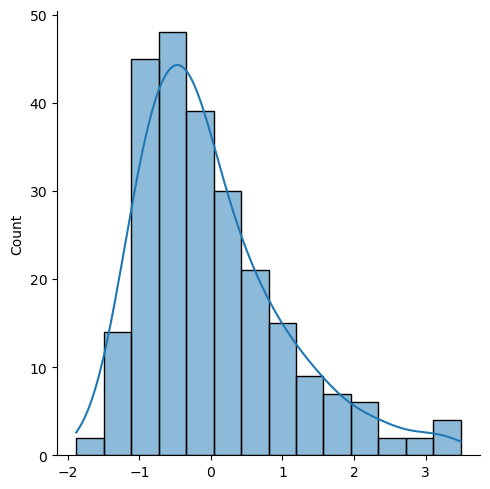

In [10]:
#feature scaling is optional>> it doesnotchange the distribution of the data
#let's prove it
sns.displot(std_data,kde=True)


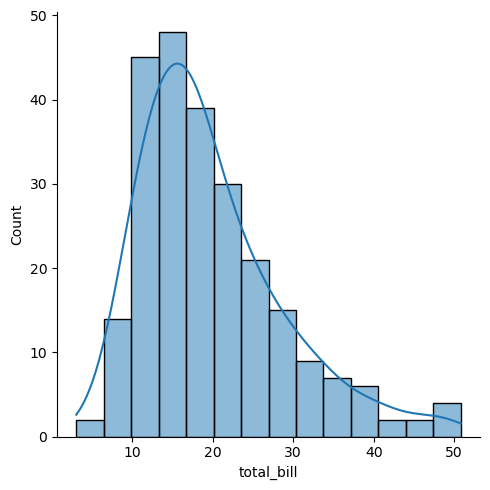

In [11]:
sns.displot(df['total_bill'], kde=True)


In [12]:
#standardisation using library (sklearn)
from sklearn.preprocessing import StandardScaler


In [13]:
scaler = StandardScaler()
scaler #creating object of a class

StandardScaler()

In [14]:
'''stpes for standardisation using library
-> .fit() : calculating mua and std
-> .tranform() : apply the calculation (Zscore)'''
scaler.fit(df[['total_bill']])  #it will calculate mean and sigma


StandardScaler()

In [15]:
scaler.transform(df[['total_bill']])

array([[-3.14711305e-01],
       [-1.06323531e+00],
       [ 1.37779900e-01],
       [ 4.38315103e-01],
       [ 5.40744704e-01],
       [ 6.19536705e-01],
       [-1.23995452e+00],
       [ 7.98507107e-01],
       [-5.34203307e-01],
       [-5.63468908e-01],
       [-1.07111451e+00],
       [ 1.74175992e+00],
       [-4.91430507e-01],
       [-1.52624903e-01],
       [-5.57840908e-01],
       [ 2.01939101e-01],
       [-1.06436091e+00],
       [-3.93503306e-01],
       [-3.16962505e-01],
       [ 9.72582994e-02],
       [-2.10030504e-01],
       [ 5.67366990e-02],
       [-4.52034507e-01],
       [ 2.21000952e+00],
       [ 3.83349840e-03],
       [-2.22412104e-01],
       [-7.22178510e-01],
       [-7.98719310e-01],
       [ 2.15446301e-01],
       [-1.53017018e-02],
       [-1.15215771e+00],
       [-1.61629703e-01],
       [-5.31952107e-01],
       [ 1.01760699e-01],
       [-2.25788904e-01],
       [ 4.81087904e-01],
       [-3.91252106e-01],
       [-3.21464905e-01],
       [-1.2

In [16]:
#we can do both in one domain
scaler.fit_transform(df[['total_bill','tip']])

array([[-3.14711305e-01, -1.43994695e+00],
       [-1.06323531e+00, -9.69205340e-01],
       [ 1.37779900e-01,  3.63355539e-01],
       [ 4.38315103e-01,  2.25754144e-01],
       [ 5.40744704e-01,  4.43019505e-01],
       [ 6.19536705e-01,  1.23965916e+00],
       [-1.23995452e+00, -7.22971264e-01],
       [ 7.98507107e-01,  8.81527488e-02],
       [-5.34203307e-01, -7.51939979e-01],
       [-5.63468908e-01,  1.67816714e-01],
       [-1.07111451e+00, -9.32994446e-01],
       [ 1.74175992e+00,  1.44968234e+00],
       [-4.91430507e-01, -1.03438495e+00],
       [-1.52624903e-01,  1.24660453e-03],
       [-5.57840908e-01,  1.57309619e-02],
       [ 2.01939101e-01,  6.67527044e-01],
       [-1.06436091e+00, -9.61963161e-01],
       [-3.93503306e-01,  5.15441291e-01],
       [-3.16962505e-01,  3.63355539e-01],
       [ 9.72582994e-02,  2.54722859e-01],
       [-2.10030504e-01,  7.83401903e-01],
       [ 5.67366990e-02, -1.79807863e-01],
       [-4.52034507e-01, -5.56401155e-01],
       [ 2.

In [18]:
#pass it in dataframe
pd.DataFrame(scaler.fit_transform(df[['total_bill','tip']]), columns=['total_bill','tip'])
#here we get transformed stadardised data

,total_bill,tip
0,-0.314711,-1.439947
1,-1.063235,-0.969205
2,0.137780,0.363356
3,0.438315,0.225754
4,0.540745,0.443020
...,...,...
239,1.040511,2.115963
240,0.832275,-0.722971
241,0.324630,-0.722971
242,-0.221287,-0.904026


In [19]:
#as we know to build machine learning method, we need to divide the data 
#as train and test, where test data is representation of unseen data.
#so in train data we apply fit+transform both we happen (because it available with us)
#even we use those because we are actually training the machine learning model.
#but in test data we only perform transform because here we only want to test machine
#and machine itself need to understand it, because upcoming real world data can't be fit and transform so to test it
#we only check the transform not fit

In [ ]:
scaler.transform([[13,1]]) #the unseen data we get scaled value

array([[-0.76382571, -1.44718913]])

In [21]:
#normalization (min/max) scaling
from sklearn.preprocessing import MinMaxScaler
min_max = MinMaxScaler()
min_max

MinMaxScaler()

In [22]:
min_max.fit_transform(df[['total_bill','tip']])

array([[0.29157939, 0.00111111],
       [0.1522832 , 0.07333333],
       [0.3757855 , 0.27777778],
       [0.43171345, 0.25666667],
       [0.45077503, 0.29      ],
       [0.46543779, 0.41222222],
       [0.11939673, 0.11111111],
       [0.49874319, 0.23555556],
       [0.25073314, 0.10666667],
       [0.24528697, 0.24777778],
       [0.15081693, 0.07888889],
       [0.67427734, 0.44444444],
       [0.25869292, 0.06333333],
       [0.32174277, 0.22222222],
       [0.24633431, 0.22444444],
       [0.38772518, 0.32444444],
       [0.15207373, 0.07444444],
       [0.27691663, 0.30111111],
       [0.29116045, 0.27777778],
       [0.36824466, 0.26111111],
       [0.31105991, 0.34222222],
       [0.36070381, 0.19444444],
       [0.2660243 , 0.13666667],
       [0.761416  , 0.73111111],
       [0.35085882, 0.24222222],
       [0.30875576, 0.14888889],
       [0.21575199, 0.11111111],
       [0.20150817, 0.11111111],
       [0.39023879, 0.36666667],
       [0.34729786, 0.22222222],
       [0.

In [24]:
min_max.transform([[10,2]])

array([[0.14516129, 0.11111111]])

In [29]:
#unit vector
from sklearn.preprocessing import normalize
uv= normalize(df[['total_bill']]) #here no need to create fit transfrom direct pass the dataset

In [28]:
uv

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],

In [30]:
#problems from taxis dataset, scale -> distance, fare, tip
df = sns.load_dataset('taxis')

In [31]:
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [32]:
#using standardisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [33]:
scaler.fit_transform(df[['distance','fare','tip']])

array([[-0.37219881, -0.52732421,  0.06975269],
       [-0.58382136, -0.7004708 , -0.80838282],
       [-0.43228917, -0.48403756,  0.15552407],
       ...,
       [ 0.29140769,  0.25183542, -0.80838282],
       [-0.49760477, -0.6138975 , -0.80838282],
       [ 0.21564159,  0.16526213,  0.56395919]])

In [34]:
#using normalization
from sklearn.preprocessing import MinMaxScaler
min_max = MinMaxScaler()
min_max.fit_transform(df[['distance','fare','tip']])

array([[0.04359673, 0.04026846, 0.06475904],
       [0.02152589, 0.02684564, 0.        ],
       [0.0373297 , 0.04362416, 0.07108434],
       ...,
       [0.11280654, 0.10067114, 0.        ],
       [0.03051771, 0.03355705, 0.        ],
       [0.10490463, 0.09395973, 0.10120482]])

In [36]:
#using unit vector
from sklearn.preprocessing import normalize
uv = normalize(df[['distance','fare','tip']])
uv

array([[0.21346145, 0.93389384, 0.28683882],
       [0.15606402, 0.98774694, 0.        ],
       [0.1716575 , 0.93973084, 0.29570197],
       ...,
       [0.25050016, 0.96811656, 0.        ],
       [0.18349711, 0.98302025, 0.        ],
       [0.2429556 , 0.94658025, 0.21203398]])